In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (12, 5)


/home/pratham/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_excel("data-fQRS-complex-in-patients-with-ICD.xlsx")

print("=" * 60)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 60)
print("\n--- Column Names ---")
print(df.columns.tolist())
print("\n--- Data Types ---")
print(df.dtypes.value_counts())
print("\n--- First 5 Rows ---")
df.head()


Dataset Shape: 382 rows × 99 columns

--- Column Names ---
['Number', 'age (at implant)', 'sex', 'date of implant', 'primary prevention', 'type of arrhythmia at implantation', 'arrhythmia rate ', 'VT - EPS', 'syncope', 'SCD', 'CAD', 'history of MI', 'number of MI', 'history of STEMI', 'STEMI localization', 'history of NSTEMI', 'NSTEMI localization', 'history of CABG/PCI', 'LAD stents/grafts', 'Cx stents/grafts', 'RCA stents/grafts', 'LAD disease', 'Cx disease', 'RCA disease', 'complete revascularisation', 'CABG before implant', 'PCI before implant', 'DCM', 'HCM', 'ARVD', 'other heart disease', 'NYHA', 'supraventricular tachyarrhythmia', 'paroxismal/permanent AF', 'chronic AF', 'AFL, AT', 'COPD', 'DM', 'AH', 'PAD', 'stroke/TIA', 'BMI', 'krea', 'GFR', 'hypothyroidism', 'hyperthyroidism', 'LVEDD (cm)', 'LVEF (%)', 'intermittent BBB', 'ASA', 'clopidogrel', 'VKA', 'BB', 'I class antyarrhythmic drugs', 'amiodaron', 'sotalol', 'CCB', 'ACEI/ARB', 'digoxin', 'diuretic', 'statin', 'aldosterone a

,Number,age (at implant),sex,date of implant,primary prevention,type of arrhythmia at implantation,arrhythmia rate,VT - EPS,syncope,SCD,...,paced rhytm,ICD-RV electrode,ICD-LV electrode,ICD-RA electrode,ICD- number of electrodes,ICD brand/model,indications for permanent pacing,PM before ICD,number of coils on defib electrode,complications after implant
0,183,61,1,28.07.2009,1,NaN,NaN,2,2.0,2.0,...,2.0,1,1,1,3,Med./Insync Sentry,1,2,2.0,1
1,264,74,2,16.11.2010,2,2.0,NaN,2,2.0,1.0,...,2.0,1,2,2,1,Bos./Teligen 100,2,2,1.0,2
2,113,77,1,2.01.2009,2,1.0,175.0,2,2.0,2.0,...,2.0,1,2,2,1,Med./Maximo VR,2,2,2.0,2
3,423,70,2,24.05.2011,1,NaN,NaN,2,2.0,2.0,...,2.0,1,1,1,3,Bos./Punctua,1,2,1.0,2
4,230,60,2,14.04.2010,1,NaN,NaN,2,2.0,2.0,...,2.0,1,2,2,1,Med./Maximo II VR,2,2,1.0,1


In [3]:
# All binary columns encoded as 1=Yes / 2=No
binary_cols = [
    'sex', 'primary prevention', 'VT - EPS', 'syncope', 'SCD', 'CAD',
    'history of MI', 'history of STEMI', 'history of NSTEMI',
    'history of CABG/PCI', 'LAD stents/grafts', 'Cx stents/grafts',
    'LAD disease', 'Cx disease', 'RCA disease', 'complete revascularisation',
    'CABG before implant', 'PCI before implant', 'DCM', 'HCM', 'ARVD',
    'supraventricular tachyarrhythmia', 'paroxismal/permanent AF',
    'chronic AF', 'AFL, AT', 'COPD', 'DM', 'AH', 'PAD', 'stroke/TIA',
    'hypothyroidism', 'hyperthyroidism', 'intermittent BBB',
    'ASA', 'clopidogrel', 'VKA', 'BB', 'I class antyarrhythmic drugs',
    'amiodaron', 'sotalol', 'CCB', 'ACEI/ARB', 'digoxin', 'diuretic',
    'statin', 'aldosterone antaonist', 'fQRS', 'fQRS anterior',
    'fQRS lateral', 'fQRS inferior', 'f wQRS', 'f wQRS anterior',
    'fwQRS lateral', 'fwQRS inferior', 'fQ', 'fR', 'fS',
    'Q wave', 'Q wave anterior', 'Q wave lateral', 'Q wave inferior',
    'Q wave in BBB/paced', 'LBBB', 'RBBB', 'IVCD', 'without BBB',
    'paced rhytm', 'indications for permanent pacing', 'PM before ICD',
    'complications after implant', 'other heart disease'
]

df_r = df.copy()
for c in binary_cols:
    if c in df_r.columns:
        df_r[c] = df_r[c].map({1: 1, 2: 0})

# Human-readable group label
df_r['fQRS_label'] = df_r['fQRS'].map({1: 'fQRS+', 0: 'fQRS-'})

# Separate groups for easy comparisons
fqrs_pos = df_r[df_r['fQRS'] == 1]
fqrs_neg = df_r[df_r['fQRS'] == 0]

print(f"fQRS+ group: {len(fqrs_pos)} patients")
print(f"fQRS- group: {len(fqrs_neg)} patients")


fQRS+ group: 41 patients
fQRS- group: 341 patients


Variables with missing data: 57


,Variable,Missing (%)
0,intermittent BBB,99.738220
1,NSTEMI localization,99.214660
2,arrhythmia rate,89.005236
3,STEMI localization,88.481675
4,type of arrhythmia at implantation,70.418848
5,NYHA,54.973822
6,history of STEMI,44.240838
7,history of NSTEMI,38.743455
8,LVEDD (cm),37.958115
9,LAD disease,21.989529


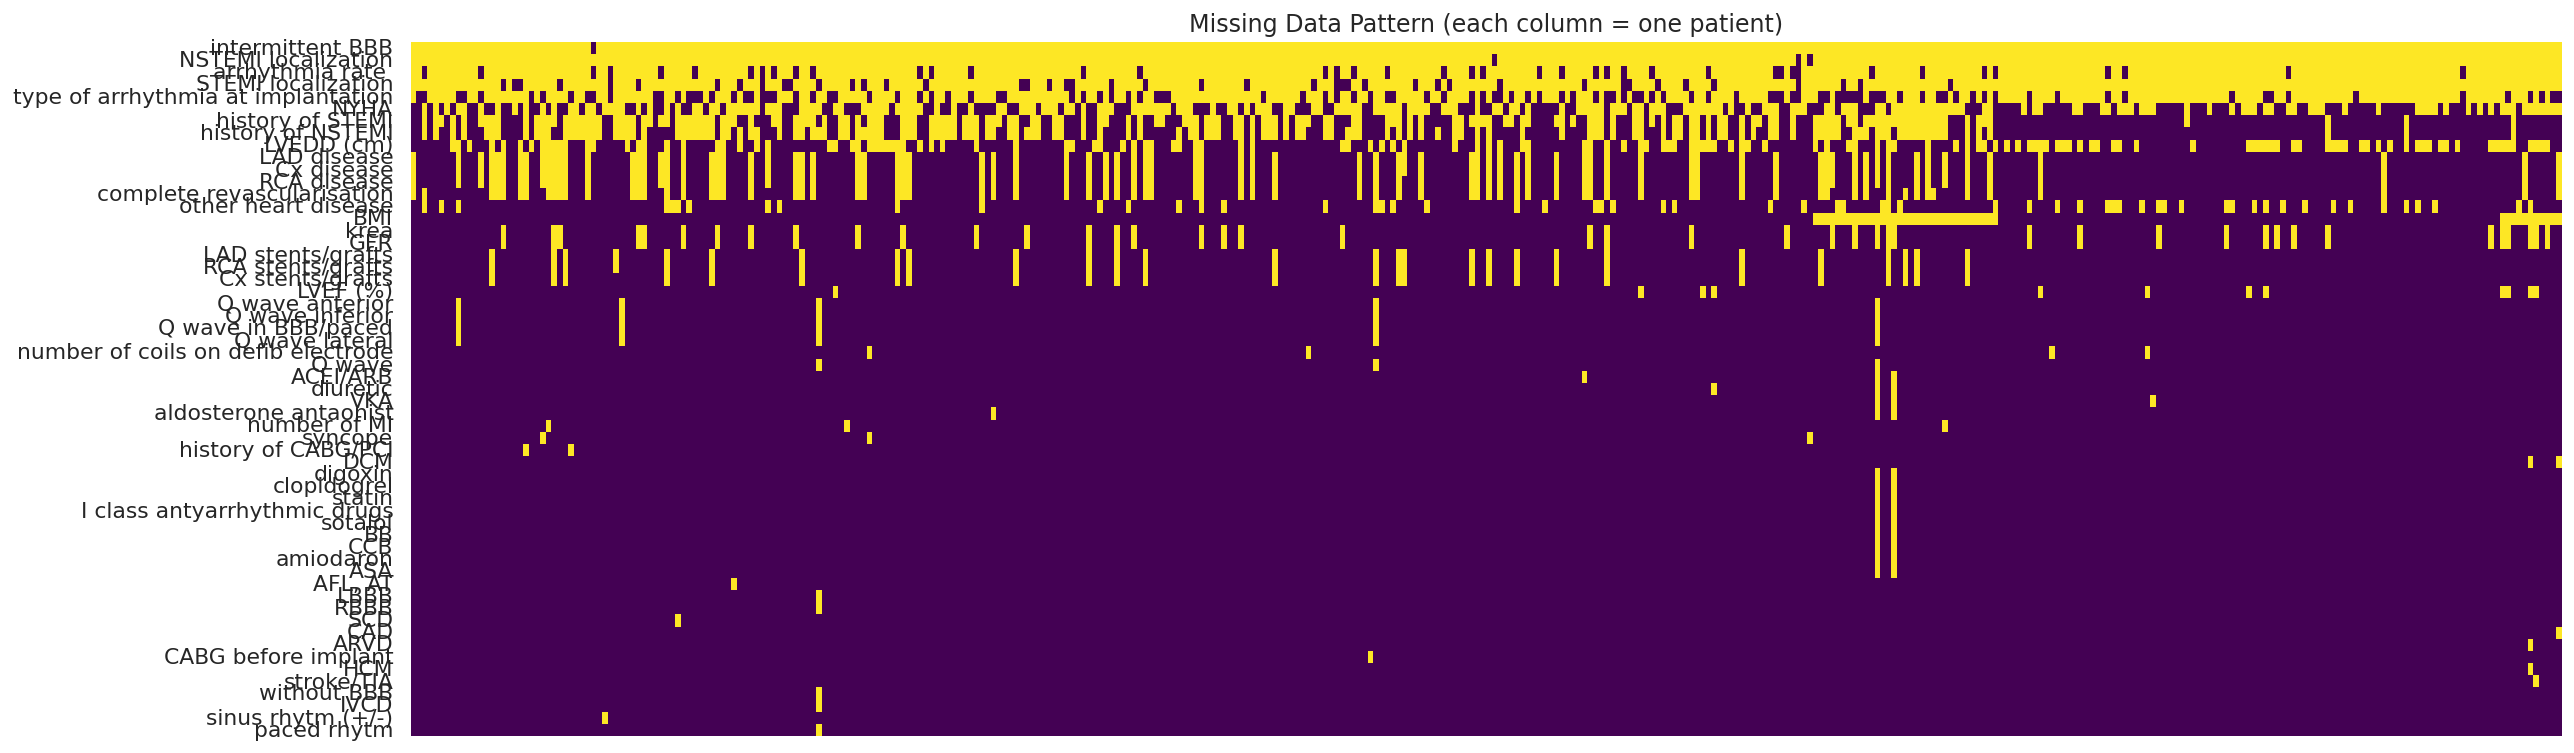

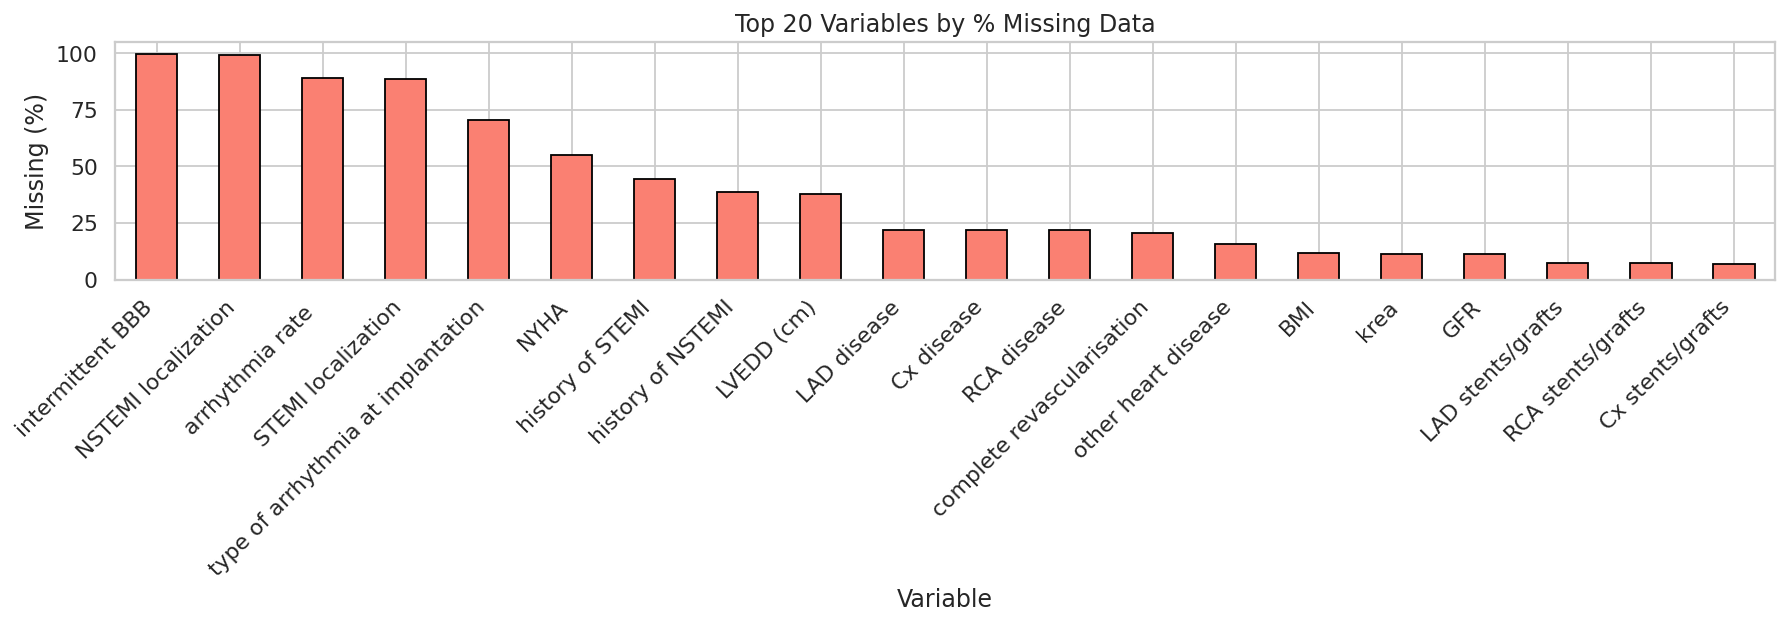

In [4]:
miss = df_r.isnull().sum()
miss_pct = (miss / len(df_r) * 100).sort_values(ascending=False)
miss_df = miss_pct[miss_pct > 0].reset_index()
miss_df.columns = ['Variable', 'Missing (%)']

print(f"Variables with missing data: {len(miss_df)}")
display(miss_df)

# Heatmap of missing data
plt.figure(figsize=(20, 6))
sns.heatmap(df_r[miss_df['Variable'].tolist()].isnull().T,
            cbar=False, yticklabels=True, xticklabels=False,
            cmap='viridis')
plt.title("Missing Data Pattern (each column = one patient)")
plt.tight_layout()
plt.show()

# Bar chart of top-20 missing
fig, ax = plt.subplots(figsize=(14, 5))
miss_df.head(20).plot.bar(x='Variable', y='Missing (%)', ax=ax,
                           color='salmon', edgecolor='black', legend=False)
ax.set_title("Top 20 Variables by % Missing Data")
ax.set_ylabel("Missing (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


fQRS Distribution:
              Count  Percent (%)
fQRS                            
fQRS Absent     341         89.3
fQRS Present     41         10.7


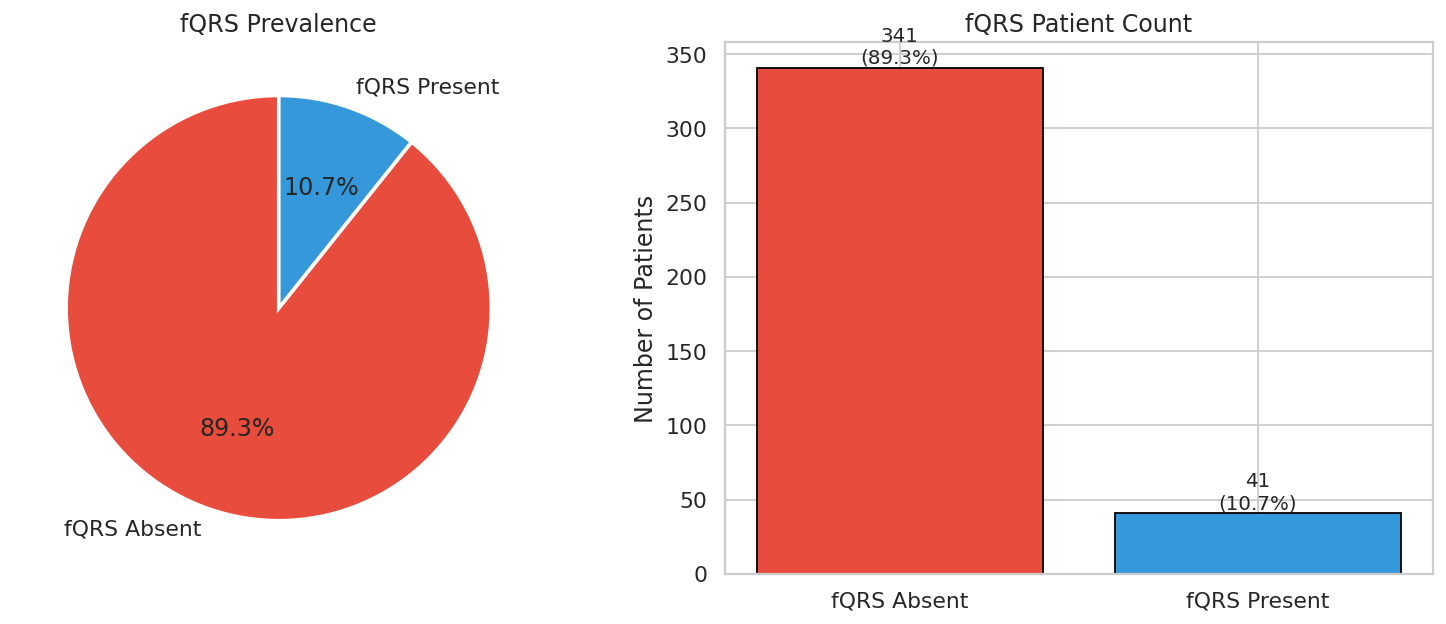

In [5]:
counts = df_r['fQRS'].value_counts().rename({1: 'fQRS Present', 0: 'fQRS Absent'})
pct = (counts / counts.sum() * 100).round(1)

print("fQRS Distribution:")
print(pd.DataFrame({'Count': counts, 'Percent (%)': pct}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#e74c3c','#3498db'], startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[0].set_title("fQRS Prevalence")

# Count bar
axes[1].bar(counts.index, counts.values,
            color=['#e74c3c','#3498db'], edgecolor='black')
for i, (val, pct_val) in enumerate(zip(counts.values, pct.values)):
    axes[1].text(i, val + 3, f"{val}\n({pct_val}%)", ha='center', fontsize=11)
axes[1].set_title("fQRS Patient Count")
axes[1].set_ylabel("Number of Patients")

plt.tight_layout()
plt.show()


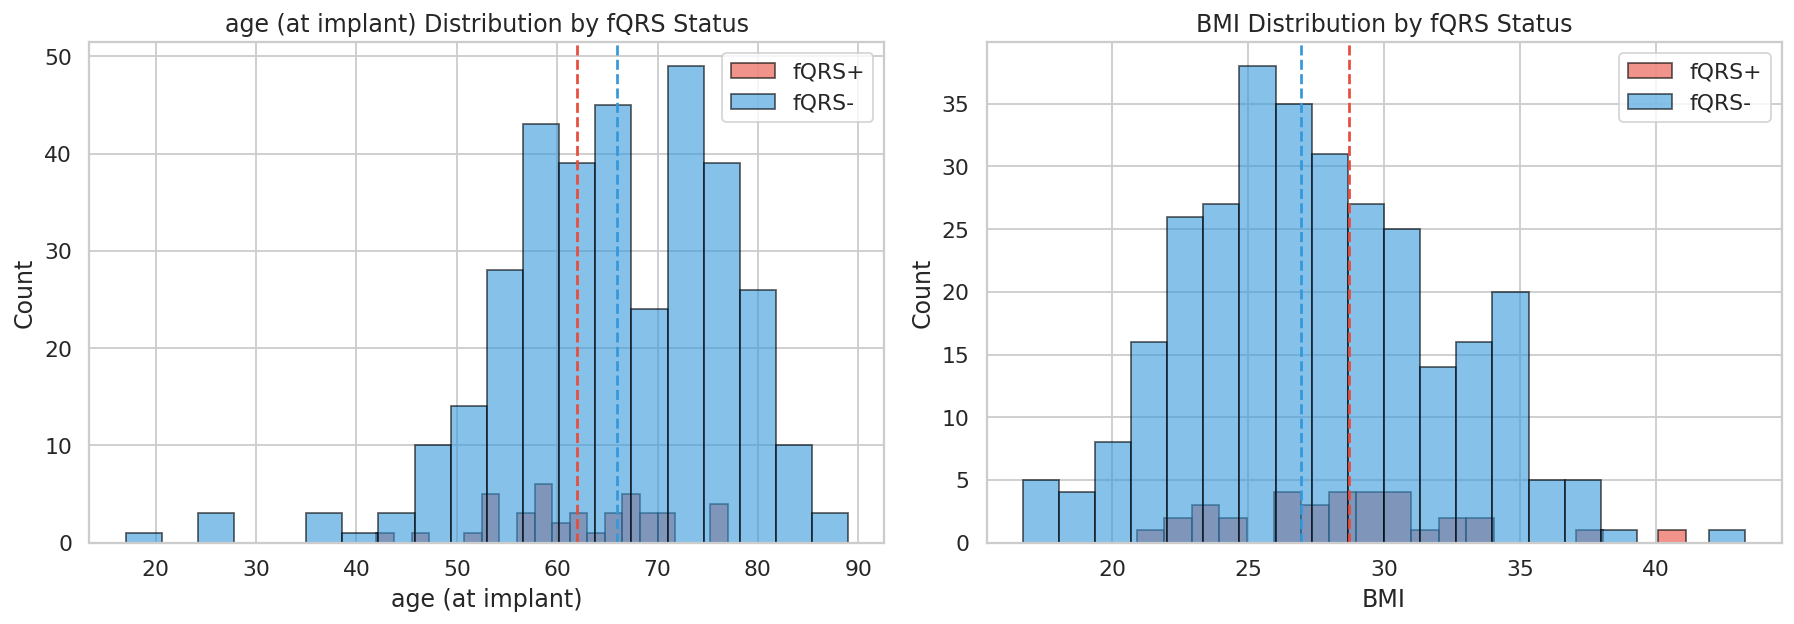


Sex × fQRS Crosstab:
 sex         Female  Male  All
fQRS_label                   
fQRS+            5    36   41
fQRS-           58   283  341
All             63   319  382

Chi² = 0.316, p = 0.5741, df = 1


In [6]:
cont_vars = ['age (at implant)', 'BMI']
fig, axes = plt.subplots(1, len(cont_vars), figsize=(14, 5))

for ax, var in zip(axes, cont_vars):
    for label, color in [('fQRS+', '#e74c3c'), ('fQRS-', '#3498db')]:
        data = df_r[df_r['fQRS_label'] == label][var].dropna()
        ax.hist(data, bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
        ax.axvline(data.median(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(f"{var} Distribution by fQRS Status")
    ax.set_xlabel(var)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

# Sex breakdown
sex_tbl = pd.crosstab(df_r['fQRS_label'],
                       df_r['sex'].map({1: 'Male', 0: 'Female'}),
                       margins=True)
print("\nSex × fQRS Crosstab:\n", sex_tbl)

chi2, p, dof, _ = chi2_contingency(
    pd.crosstab(df_r['fQRS'], df_r['sex'].map({1: 'Male', 0: 'Female'})))
print(f"\nChi² = {chi2:.3f}, p = {p:.4f}, df = {dof}")


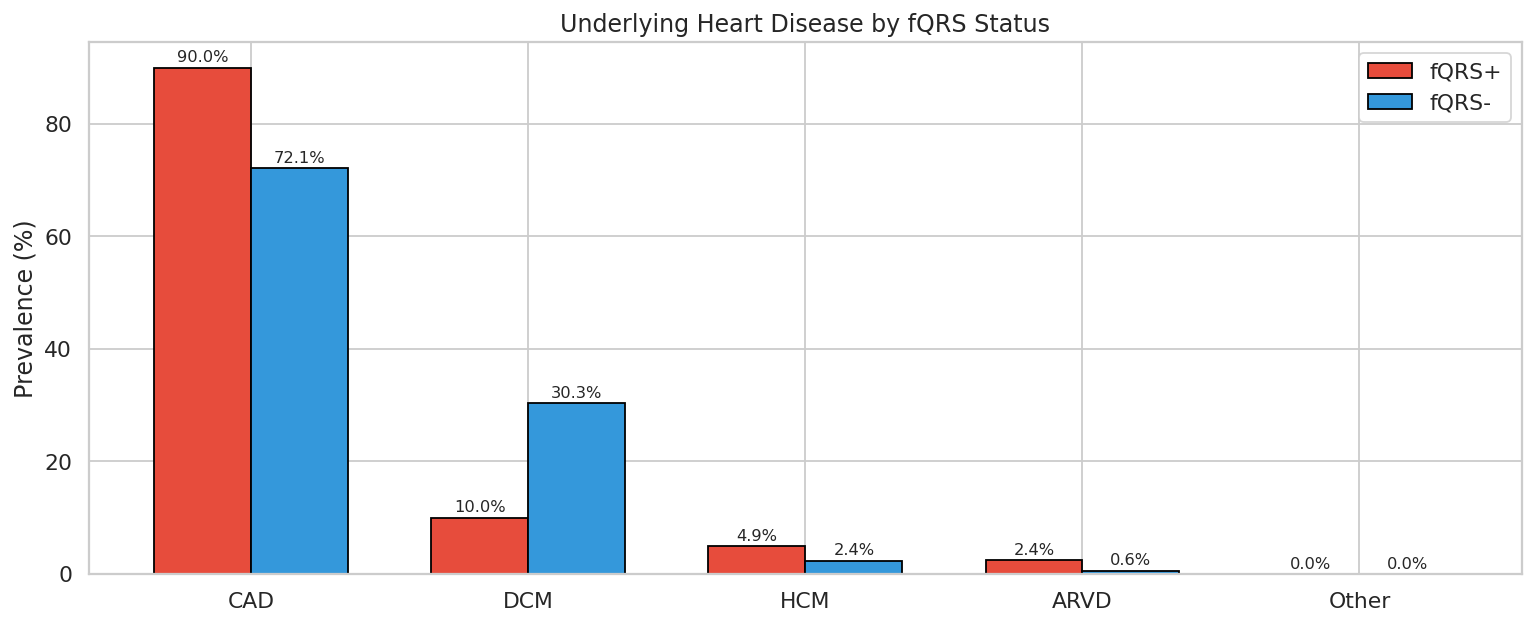

In [7]:
disease_cols = ['CAD', 'DCM', 'HCM', 'ARVD', 'other heart disease']
disease_labels = ['CAD', 'DCM', 'HCM', 'ARVD', 'Other']

prevalence = {}
for col, label in zip(disease_cols, disease_labels):
    prev_pos = fqrs_pos[col].mean() * 100 if col in df_r.columns else 0
    prev_neg = fqrs_neg[col].mean() * 100 if col in df_r.columns else 0
    prevalence[label] = {'fQRS+': prev_pos, 'fQRS-': prev_neg}

prev_df = pd.DataFrame(prevalence).T.reset_index()
prev_df.columns = ['Disease', 'fQRS+', 'fQRS-']

x = np.arange(len(prev_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, prev_df['fQRS+'], width, label='fQRS+',
               color='#e74c3c', edgecolor='black')
bars2 = ax.bar(x + width/2, prev_df['fQRS-'], width, label='fQRS-',
               color='#3498db', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(prev_df['Disease'])
ax.set_ylabel("Prevalence (%)")
ax.set_title("Underlying Heart Disease by fQRS Status")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5, f"{bar.get_height():.1f}%",
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5, f"{bar.get_height():.1f}%",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


 Comorbidity  fQRS+ (%)  fQRS- (%)  p-value
    Diabetes       31.7       29.0   0.8619
Hypertension       56.1       58.4   0.9127
        COPD       12.2       11.4   1.0000
         PAD        7.3        9.4   0.8831
  Stroke/TIA        9.8        8.5   1.0000
 Hypothyroid        2.4        3.8   0.9982
Hyperthyroid        7.3        4.4   0.6577
  Chronic AF        7.3       13.8   0.3603
    Parox AF       12.2       20.2   0.3070
         SVT       31.7       37.8   0.5516


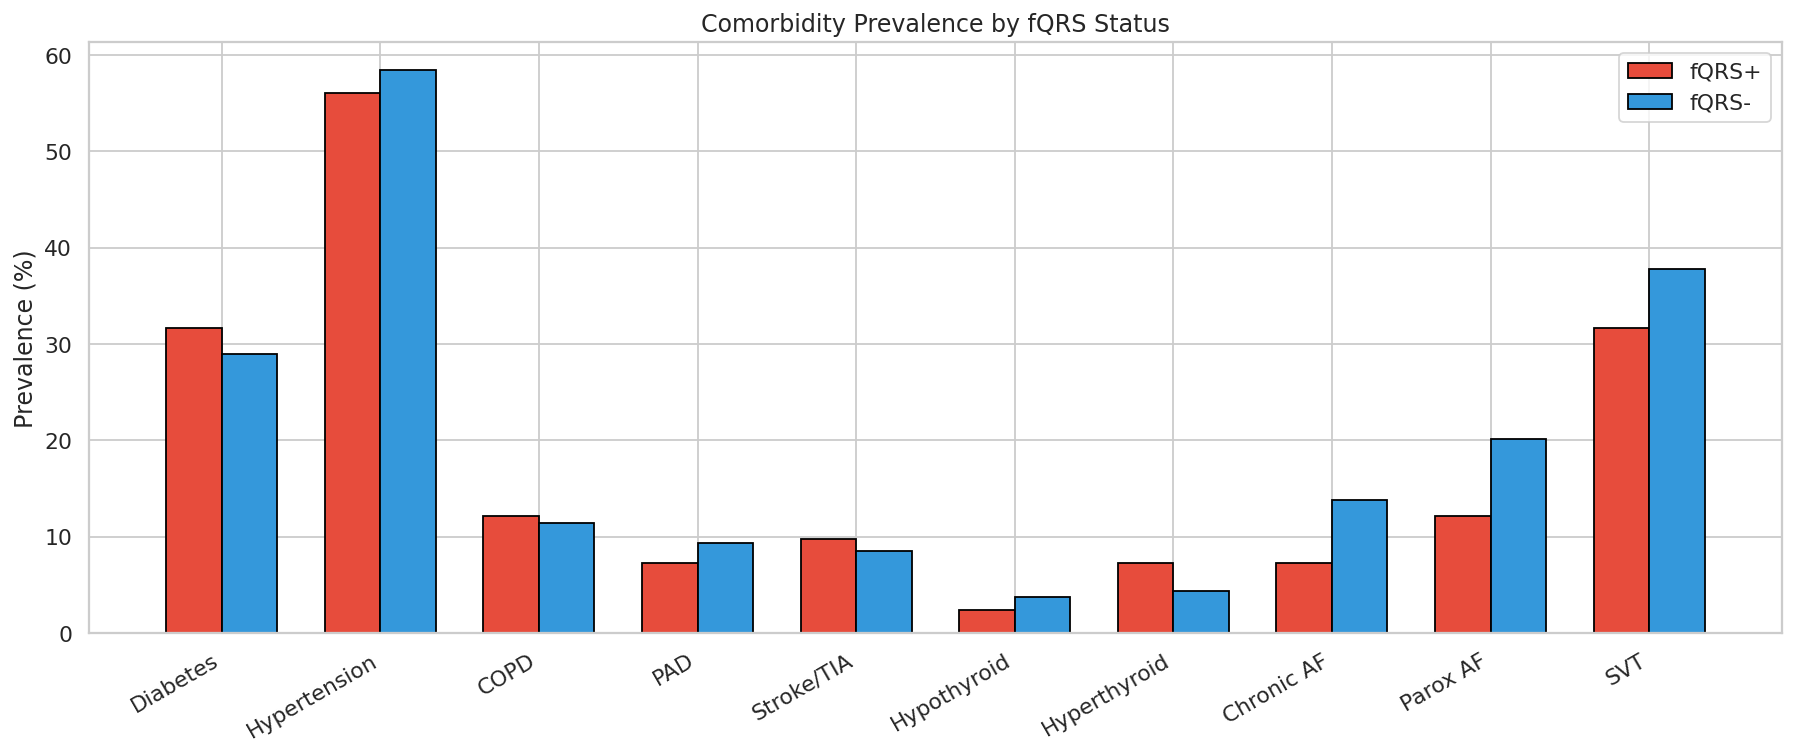

In [8]:
comorbidity_cols = ['DM', 'AH', 'COPD', 'PAD', 'stroke/TIA',
                    'hypothyroidism', 'hyperthyroidism', 'chronic AF',
                    'paroxismal/permanent AF', 'supraventricular tachyarrhythmia']

comorbidity_labels = ['Diabetes', 'Hypertension', 'COPD', 'PAD',
                      'Stroke/TIA', 'Hypothyroid', 'Hyperthyroid',
                      'Chronic AF', 'Parox AF', 'SVT']

results = []
for col, label in zip(comorbidity_cols, comorbidity_labels):
    if col in df_r.columns:
        prev_pos = fqrs_pos[col].mean() * 100
        prev_neg = fqrs_neg[col].mean() * 100
        ct = pd.crosstab(df_r['fQRS'], df_r[col].fillna(0).astype(int))
        if ct.shape == (2, 2):
            chi2_val, p_val, _, _ = chi2_contingency(ct)
        else:
            p_val = np.nan
        results.append({'Comorbidity': label, 'fQRS+ (%)': round(prev_pos, 1),
                        'fQRS- (%)': round(prev_neg, 1), 'p-value': round(p_val, 4)})

comorbidity_df = pd.DataFrame(results)
print(comorbidity_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(comorbidity_df))
width = 0.35
ax.bar(x - width/2, comorbidity_df['fQRS+ (%)'], width,
       label='fQRS+', color='#e74c3c', edgecolor='black')
ax.bar(x + width/2, comorbidity_df['fQRS- (%)'], width,
       label='fQRS-', color='#3498db', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(comorbidity_df['Comorbidity'], rotation=30, ha='right')
ax.set_ylabel("Prevalence (%)")
ax.set_title("Comorbidity Prevalence by fQRS Status")
ax.legend()
plt.tight_layout()
plt.show()


      Medication  fQRS+ (%)  fQRS- (%)  p-value
             ASA       82.9       68.7   0.0810
     Clopidogrel       29.3       26.5   0.8365
             VKA       26.8       30.2   0.8200
    Beta-Blocker       92.7       91.7   0.9803
      Class I AA        0.0        0.0      NaN
      Amiodarone       22.0       32.4   0.2428
         Sotalol        4.9        1.8   0.4591
             CCB       12.2       10.0   0.8638
        ACEI/ARB       87.8       87.6   1.0000
         Digoxin       14.6       17.7   0.7985
        Diuretic       73.2       75.7   0.9404
          Statin       92.7       75.8   0.0214
Aldosterone Ant.       56.1       58.9   0.9127


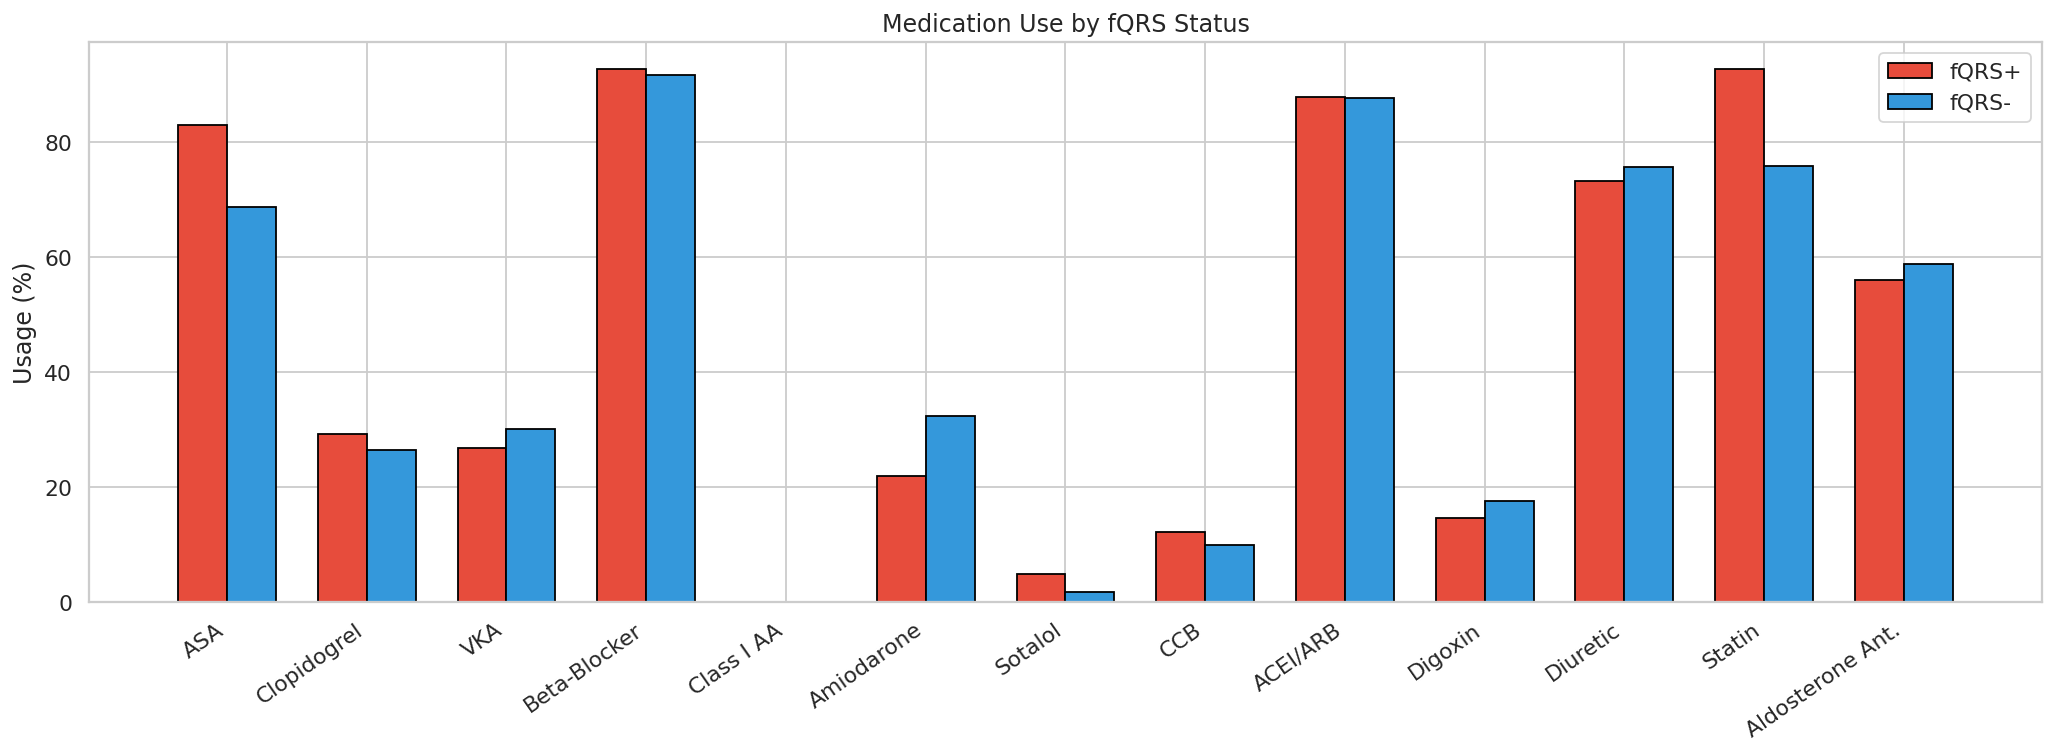

In [9]:
med_cols = ['ASA', 'clopidogrel', 'VKA', 'BB', 'I class antyarrhythmic drugs',
            'amiodaron', 'sotalol', 'CCB', 'ACEI/ARB', 'digoxin',
            'diuretic', 'statin', 'aldosterone antaonist']
med_labels = ['ASA', 'Clopidogrel', 'VKA', 'Beta-Blocker', 'Class I AA',
              'Amiodarone', 'Sotalol', 'CCB', 'ACEI/ARB', 'Digoxin',
              'Diuretic', 'Statin', 'Aldosterone Ant.']

med_results = []
for col, label in zip(med_cols, med_labels):
    if col in df_r.columns:
        prev_pos = fqrs_pos[col].mean() * 100
        prev_neg = fqrs_neg[col].mean() * 100
        ct = pd.crosstab(df_r['fQRS'], df_r[col].fillna(0).astype(int))
        if ct.shape == (2, 2):
            _, p_val, _, _ = chi2_contingency(ct)
        else:
            p_val = np.nan
        med_results.append({'Medication': label,
                             'fQRS+ (%)': round(prev_pos, 1),
                             'fQRS- (%)': round(prev_neg, 1),
                             'p-value': round(p_val, 4)})

med_df = pd.DataFrame(med_results)
print(med_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(med_df))
width = 0.35
ax.bar(x - width/2, med_df['fQRS+ (%)'], width,
       label='fQRS+', color='#e74c3c', edgecolor='black')
ax.bar(x + width/2, med_df['fQRS- (%)'], width,
       label='fQRS-', color='#3498db', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(med_df['Medication'], rotation=35, ha='right')
ax.set_ylabel("Usage (%)")
ax.set_title("Medication Use by fQRS Status")
ax.legend()
plt.tight_layout()
plt.show()


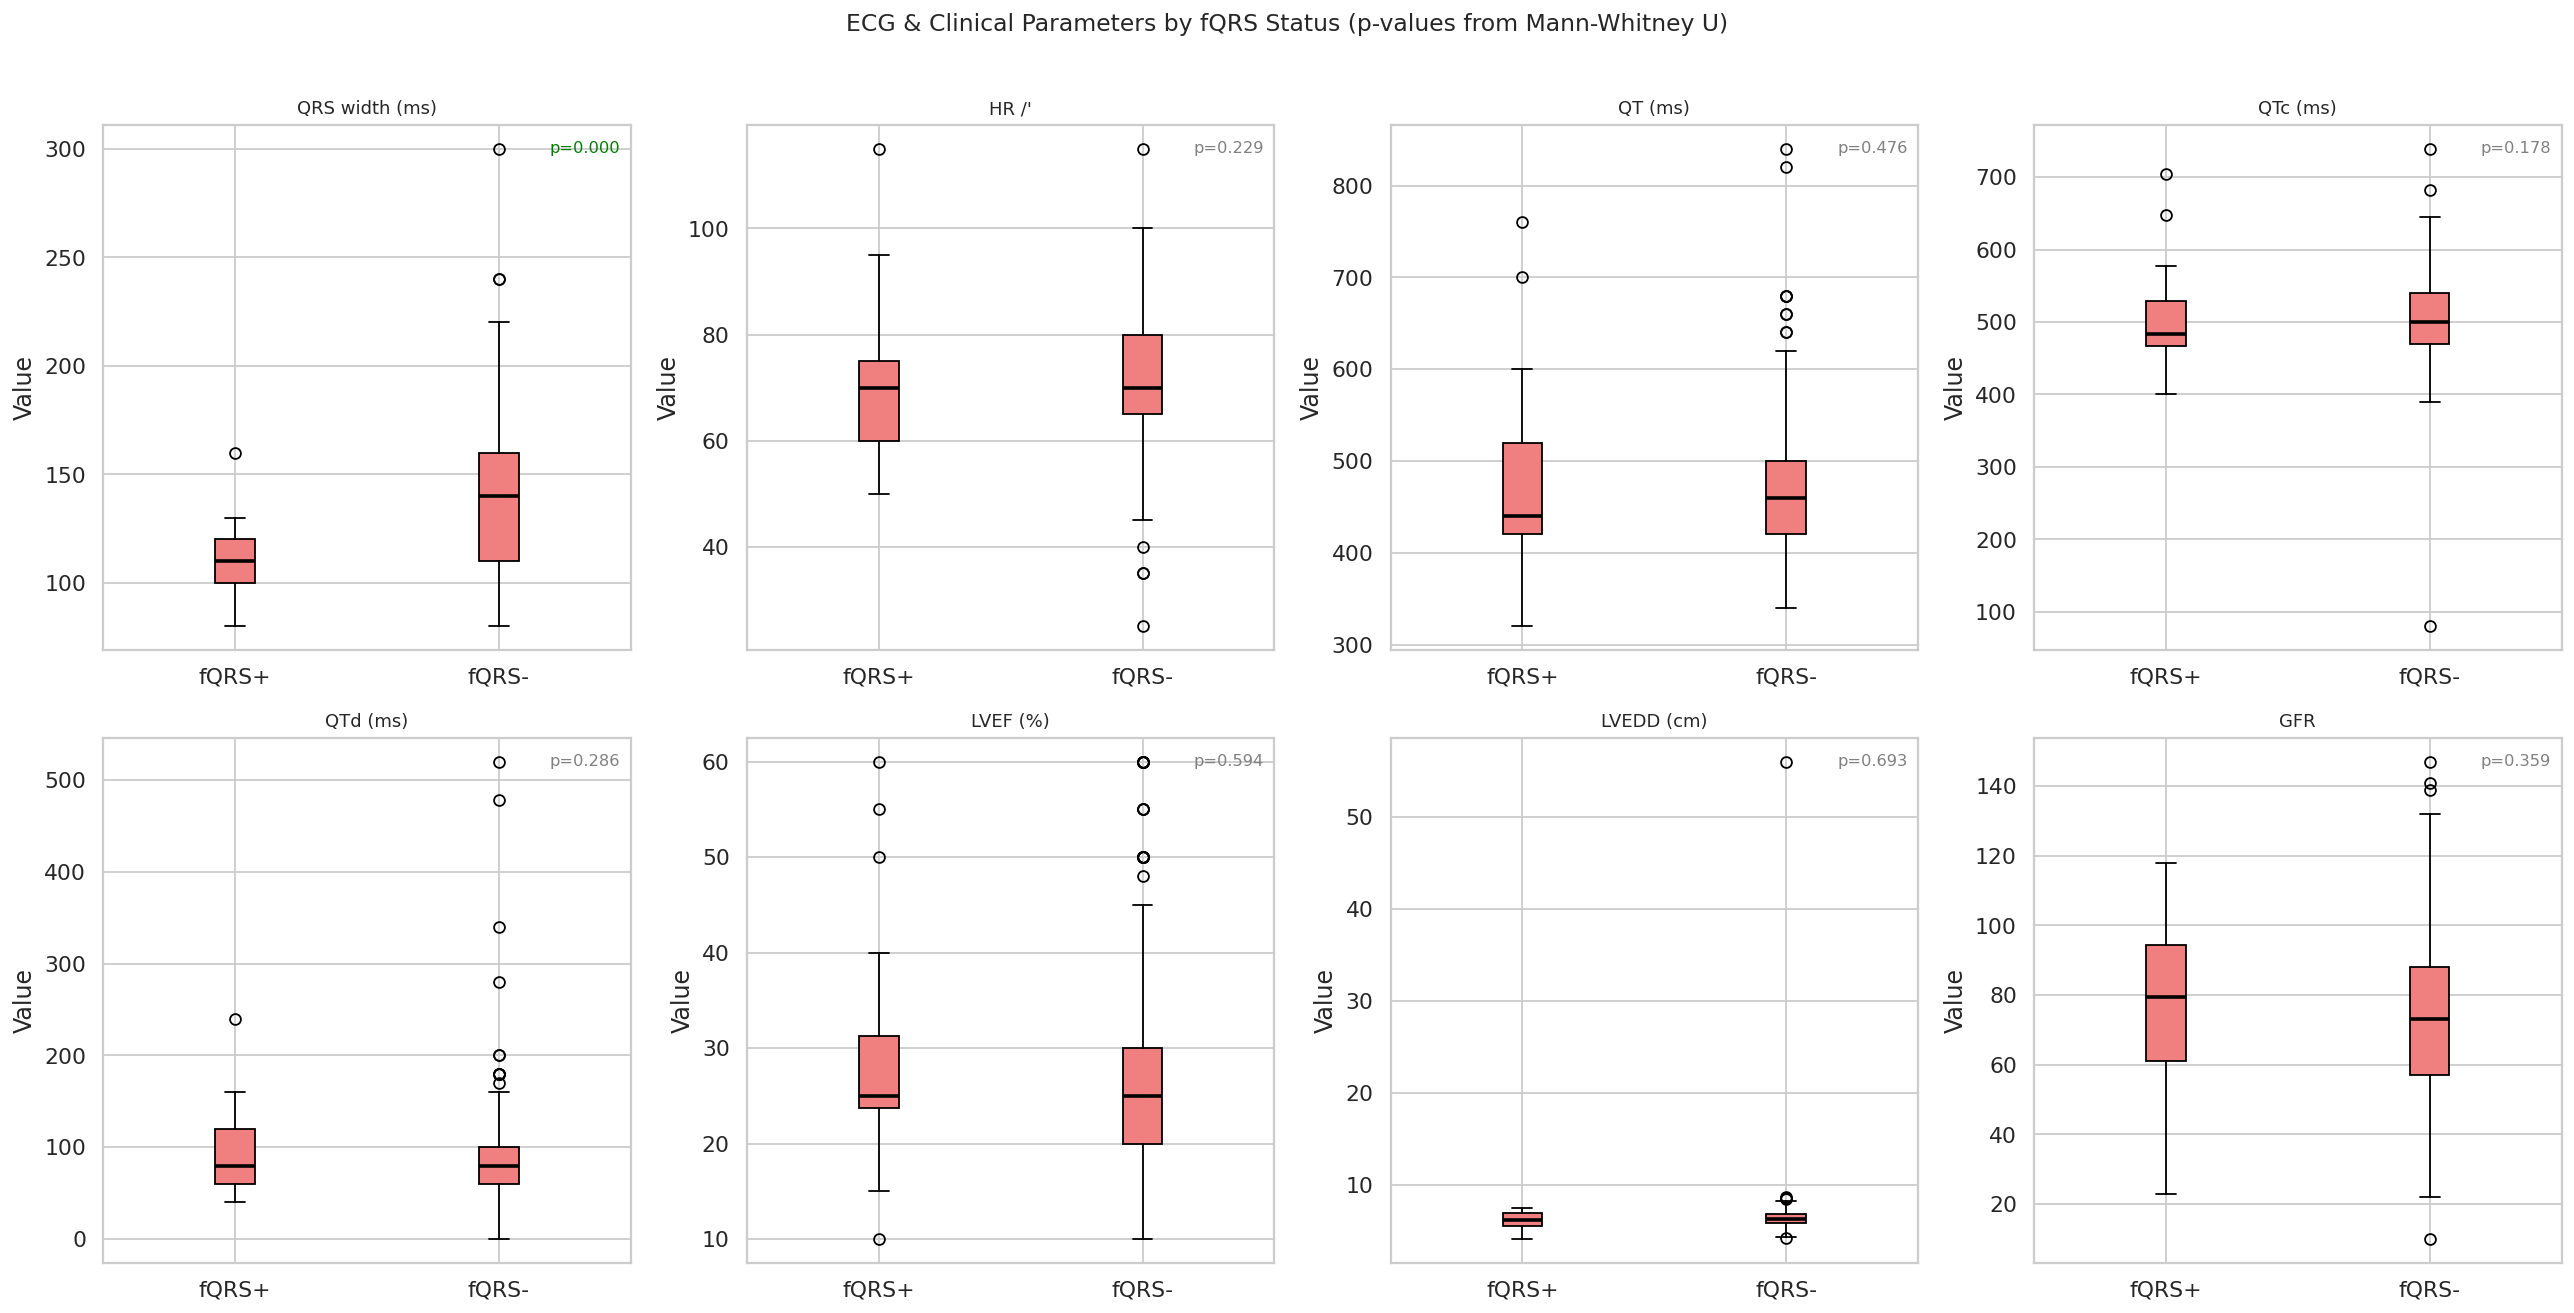


--- ECG/Clinical Summary Table ---


,Variable,fQRS+ Median,fQRS+ IQR,fQRS- Median,fQRS- IQR,MWU p-value
0,QRS width (ms),110.0,100.0–120.0,140.0,110.0–160.0,0.0000
1,HR /',70.0,60.0–75.0,70.0,65.0–80.0,0.2290
2,QT (ms),440.0,420.0–520.0,460.0,420.0–500.0,0.4760
3,QTc (ms),484.0,467.0–529.0,500.0,470.0–540.0,0.1780
4,QTd (ms),80.0,60.0–120.0,80.0,60.0–100.0,0.2861
5,LVEF (%),25.0,23.8–31.2,25.0,20.0–30.0,0.5942
6,LVEDD (cm),6.2,5.5–6.9,6.3,5.8–6.8,0.6929
7,GFR,79.5,61.0–94.2,73.0,57.0–88.0,0.3591


In [10]:
ecg_cols = ['QRS width (ms)', "HR /'", 'QT (ms)', 'QTc (ms)', 'QTd (ms)', 'LVEF (%)', 'LVEDD (cm)', 'GFR']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

summary_rows = []
for i, col in enumerate(ecg_cols):
    ax = axes[i]
    pos_data = fqrs_pos[col].dropna()
    neg_data = fqrs_neg[col].dropna()

    ax.boxplot([pos_data, neg_data], labels=['fQRS+', 'fQRS-'],
               patch_artist=True,
               boxprops=dict(facecolor='lightcoral', color='black'),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Value")

    # Mann-Whitney U test
    stat, p = mannwhitneyu(pos_data, neg_data, alternative='two-sided')
    ax.text(0.98, 0.97, f"p={p:.3f}", transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            color='green' if p < 0.05 else 'gray')

    summary_rows.append({
        'Variable': col,
        'fQRS+ Median': round(pos_data.median(), 2),
        'fQRS+ IQR': f"{round(pos_data.quantile(0.25),1)}–{round(pos_data.quantile(0.75),1)}",
        'fQRS- Median': round(neg_data.median(), 2),
        'fQRS- IQR': f"{round(neg_data.quantile(0.25),1)}–{round(neg_data.quantile(0.75),1)}",
        'MWU p-value': round(p, 4)
    })

plt.suptitle("ECG & Clinical Parameters by fQRS Status (p-values from Mann-Whitney U)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

summary_ecg = pd.DataFrame(summary_rows)
print("\n--- ECG/Clinical Summary Table ---")
display(summary_ecg)


     Feature  fQRS+ (%)  fQRS- (%)  p-value
        LBBB        0.0       26.5   0.0004
        RBBB        2.4        6.5   0.5009
        IVCD        2.4       22.1   0.0058
      No BBB       95.1       39.1   0.0000
Paced Rhythm        0.0        5.3   0.2640
      Q Wave       63.4       59.5   0.7021
      Q Ant.       51.2       18.5   0.0000
      Q Lat.        7.3       11.3   0.6306
      Q Inf.       31.7       25.9   0.5064


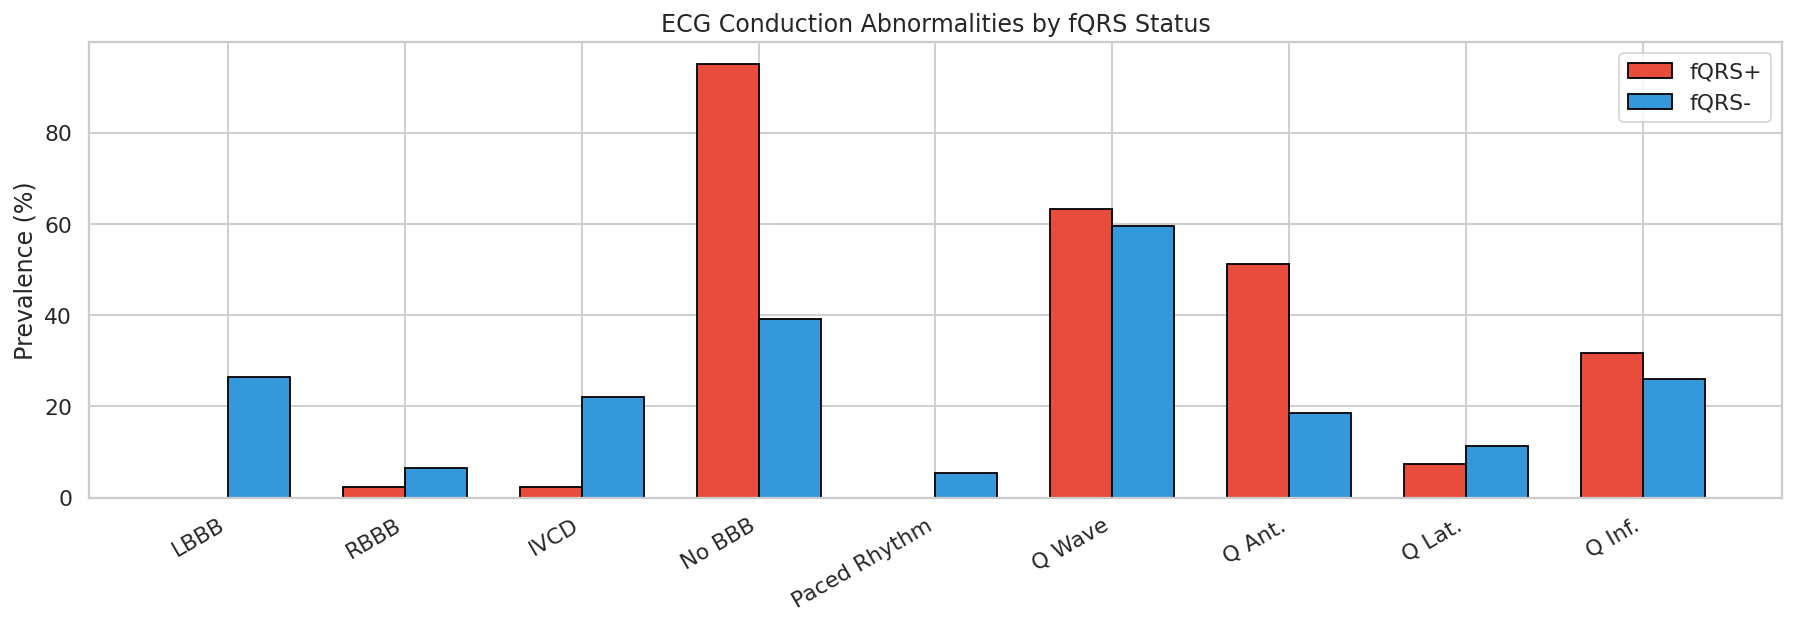

In [11]:
ecg_binary = ['LBBB', 'RBBB', 'IVCD', 'without BBB',
              'paced rhytm', 'Q wave', 'Q wave anterior',
              'Q wave lateral', 'Q wave inferior']
ecg_labels = ['LBBB', 'RBBB', 'IVCD', 'No BBB',
              'Paced Rhythm', 'Q Wave', 'Q Ant.', 'Q Lat.', 'Q Inf.']

ecg_bin_results = []
for col, label in zip(ecg_binary, ecg_labels):
    if col in df_r.columns:
        prev_pos = fqrs_pos[col].mean() * 100
        prev_neg = fqrs_neg[col].mean() * 100
        ct = pd.crosstab(df_r['fQRS'], df_r[col].fillna(0).astype(int))
        if ct.shape == (2, 2):
            _, p_val, _, _ = chi2_contingency(ct)
        else:
            p_val = np.nan
        ecg_bin_results.append({'Feature': label,
                                 'fQRS+ (%)': round(prev_pos, 1),
                                 'fQRS- (%)': round(prev_neg, 1),
                                 'p-value': round(p_val, 4)})

ecg_bin_df = pd.DataFrame(ecg_bin_results)
print(ecg_bin_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(ecg_bin_df))
width = 0.35
ax.bar(x - width/2, ecg_bin_df['fQRS+ (%)'], width,
       label='fQRS+', color='#e74c3c', edgecolor='black')
ax.bar(x + width/2, ecg_bin_df['fQRS- (%)'], width,
       label='fQRS-', color='#3498db', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(ecg_bin_df['Feature'], rotation=30, ha='right')
ax.set_ylabel("Prevalence (%)")
ax.set_title("ECG Conduction Abnormalities by fQRS Status")
ax.legend()
plt.tight_layout()
plt.show()


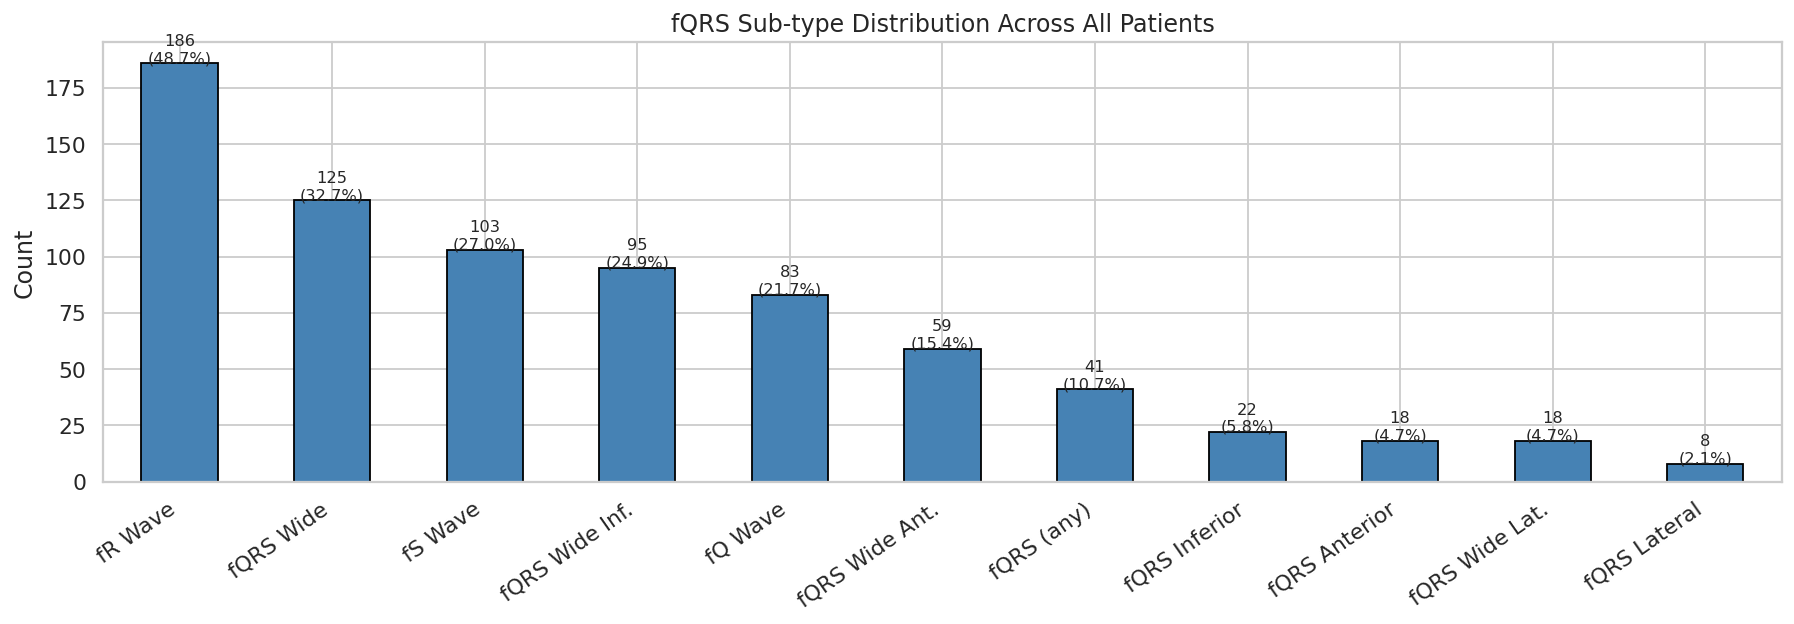

In [12]:
fqrs_subtypes = {
    'fQRS (any)': 'fQRS',
    'fQRS Anterior': 'fQRS anterior',
    'fQRS Lateral': 'fQRS lateral',
    'fQRS Inferior': 'fQRS inferior',
    'fQRS Wide': 'f wQRS',
    'fQRS Wide Ant.': 'f wQRS anterior',
    'fQRS Wide Lat.': 'fwQRS lateral',
    'fQRS Wide Inf.': 'fwQRS inferior',
    'fQ Wave': 'fQ',
    'fR Wave': 'fR',
    'fS Wave': 'fS',
}

subtype_counts = {}
for label, col in fqrs_subtypes.items():
    if col in df_r.columns:
        subtype_counts[label] = df_r[col].sum()

subtype_series = pd.Series(subtype_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
subtype_series.plot.bar(ax=ax, color='steelblue', edgecolor='black')
for i, val in enumerate(subtype_series):
    pct = val / len(df_r) * 100
    ax.text(i, val + 0.3, f"{val}\n({pct:.1f}%)", ha='center', fontsize=9)
ax.set_ylabel("Count")
ax.set_title("fQRS Sub-type Distribution Across All Patients")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()


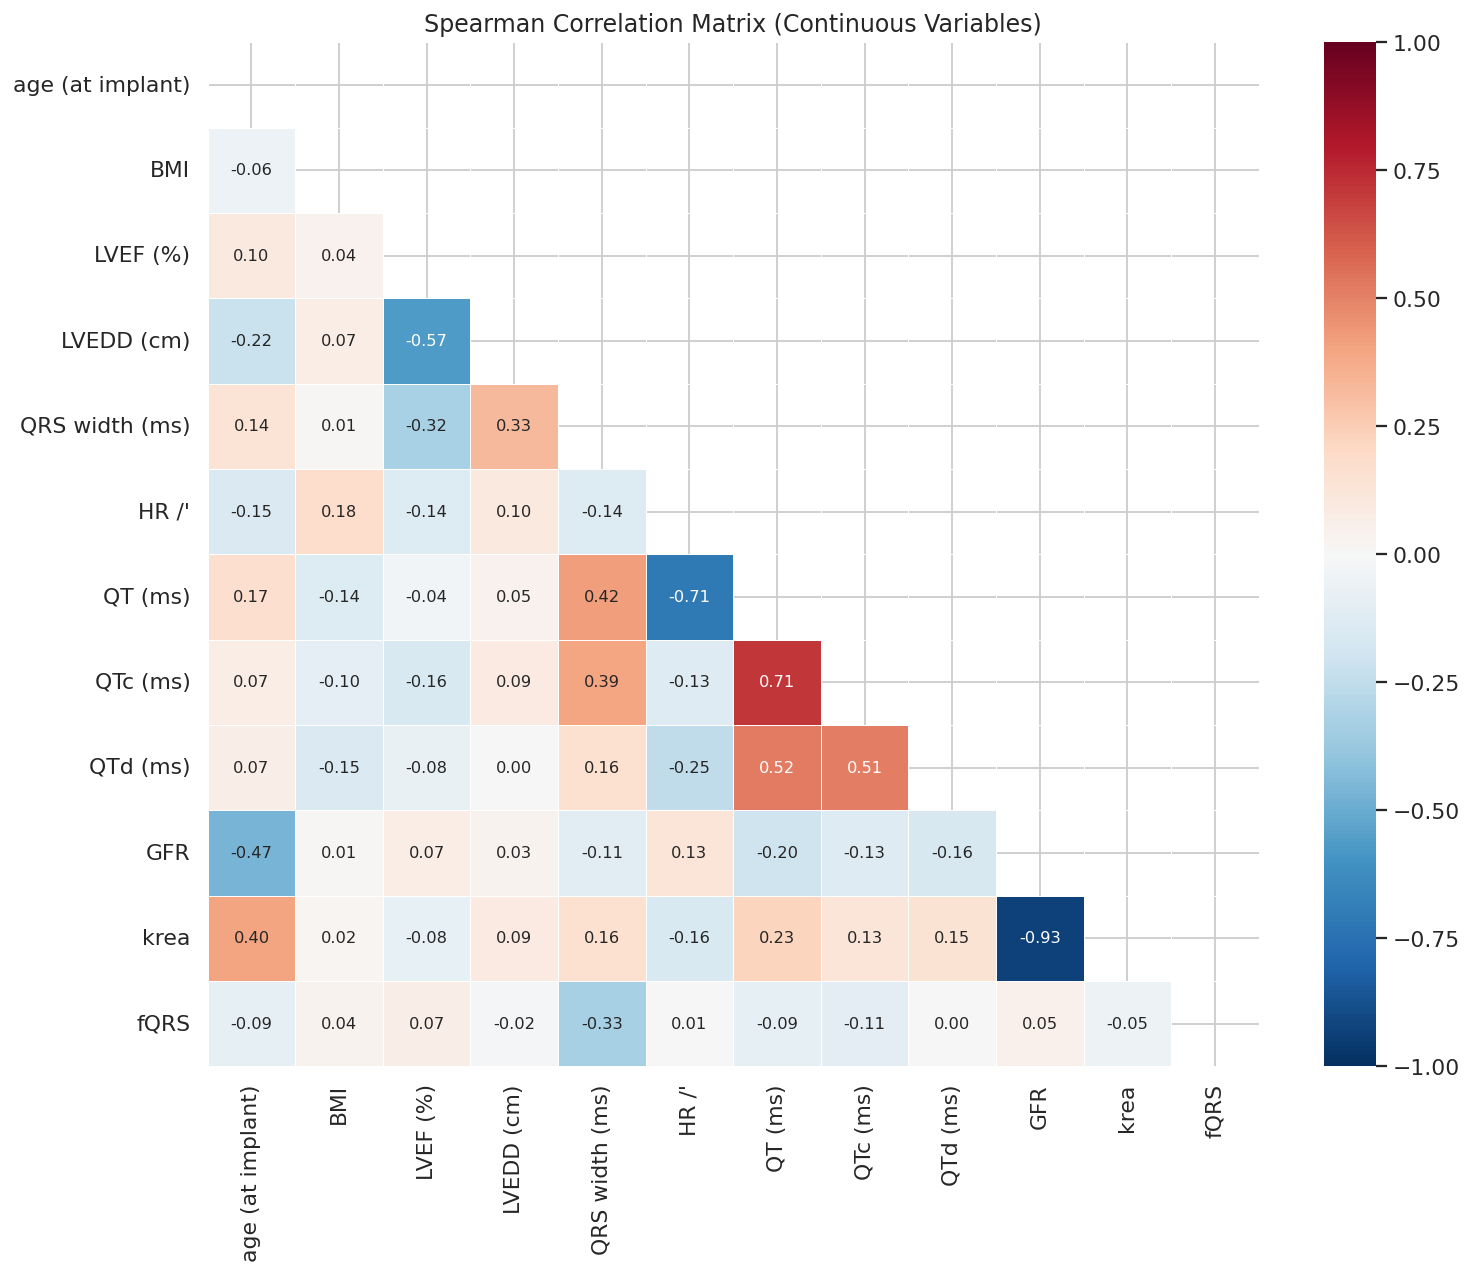

In [13]:
cont_for_corr = [
    'age (at implant)', 'BMI', 'LVEF (%)', 'LVEDD (cm)',
    'QRS width (ms)', "HR /'", 'QT (ms)', 'QTc (ms)', 'QTd (ms)',
    'GFR', 'krea', 'fQRS'
]

corr_df = df_r[cont_for_corr].dropna()
corr_matrix = corr_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title("Spearman Correlation Matrix (Continuous Variables)")
plt.tight_layout()
plt.show()


ICD Brand/Model Distribution (Top 15):
ICD brand/model
Med./Maximo II VR                        114
Med./Maximo VR                            59
Med./Maximo DR                            52
Med./Maximo II DR                         40
Bos./Punctua                              31
Bos./Teligen 100                          27
Med./Insync Maximo                        24
Med./Insync Sentry                        15
Bos./Cognis 100D                           7
Bio./Lumax 340 DR-T                        5
Med./Maximo II CRTD                        2
Bos./Teligen                               2
Med../Maximo II VR                         1
Bos./Teligen 100 (Med./Insync Maximo)      1
Med../Insync Maximo                        1
Name: count, dtype: int64

Number of ICD Electrodes:
ICD- number of electrodes
1    198
2    129
3     55
Name: count, dtype: int64

Complications after Implant by fQRS Status:
complications after implant   No  Yes  All
fQRS_label                                
fQRS+  

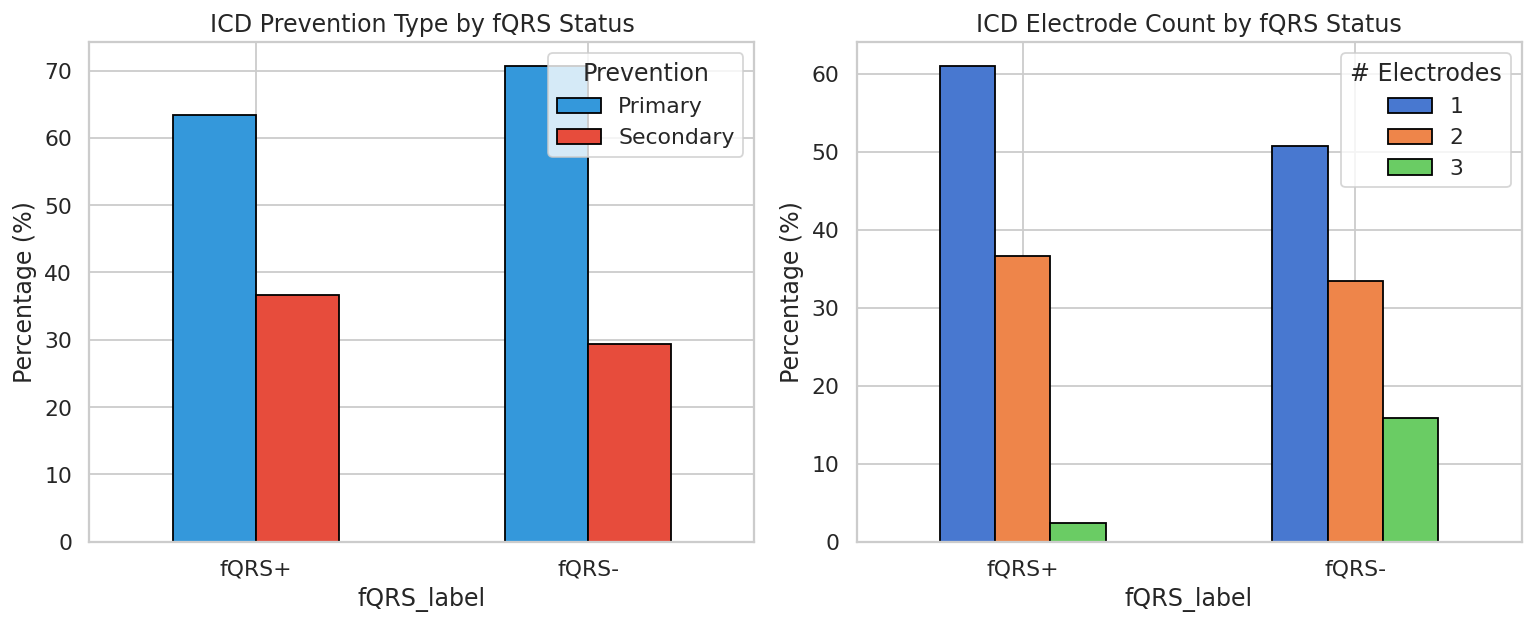

In [14]:
# Device types
print("ICD Brand/Model Distribution (Top 15):")
print(df_r['ICD brand/model'].value_counts().head(15))

# Number of electrodes
print("\nNumber of ICD Electrodes:")
print(df_r['ICD- number of electrodes'].value_counts().sort_index())

# Complications
print("\nComplications after Implant by fQRS Status:")
print(pd.crosstab(df_r['fQRS_label'],
                  df_r['complications after implant'].map({1:'Yes', 0:'No'}),
                  margins=True))

# Prevention type
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

prev_ct = pd.crosstab(df_r['fQRS_label'],
                       df_r['primary prevention'].map({1:'Primary', 0:'Secondary'}),
                       normalize='index') * 100
prev_ct.plot.bar(ax=axes[0], color=['#3498db','#e74c3c'], edgecolor='black')
axes[0].set_title("ICD Prevention Type by fQRS Status")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title="Prevention")

elec_ct = df_r.groupby('fQRS_label')['ICD- number of electrodes'].value_counts(normalize=True).unstack() * 100
elec_ct.plot.bar(ax=axes[1], edgecolor='black')
axes[1].set_title("ICD Electrode Count by fQRS Status")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="# Electrodes")

plt.tight_layout()
plt.show()


In [15]:
# Build a Table 1 style summary
from IPython.display import display

def summarize_continuous(var, group_col='fQRS', df=df_r):
    pos = df[df[group_col]==1][var].dropna()
    neg = df[df[group_col]==0][var].dropna()
    stat, p = mannwhitneyu(pos, neg, alternative='two-sided')
    return {
        'Variable': var,
        'Overall (n=382)': f"{df[var].median():.1f} [{df[var].quantile(0.25):.1f}–{df[var].quantile(0.75):.1f}]",
        'fQRS+ (n=41)': f"{pos.median():.1f} [{pos.quantile(0.25):.1f}–{pos.quantile(0.75):.1f}]",
        'fQRS- (n=341)': f"{neg.median():.1f} [{neg.quantile(0.25):.1f}–{neg.quantile(0.75):.1f}]",
        'p-value': round(p, 4),
        'Test': 'Mann-Whitney U'
    }

def summarize_binary(var, label, group_col='fQRS', df=df_r):
    pos = df[df[group_col]==1][var].dropna()
    neg = df[df[group_col]==0][var].dropna()
    all_v = df[var].dropna()
    ct = pd.crosstab(df[group_col], df[var].fillna(0).astype(int))
    p = chi2_contingency(ct)[1] if ct.shape == (2,2) else np.nan
    return {
        'Variable': label,
        'Overall (n=382)': f"{all_v.sum():.0f} ({all_v.mean()*100:.1f}%)",
        'fQRS+ (n=41)': f"{pos.sum():.0f} ({pos.mean()*100:.1f}%)",
        'fQRS- (n=341)': f"{neg.sum():.0f} ({neg.mean()*100:.1f}%)",
        'p-value': round(p, 4) if not np.isnan(p) else 'N/A',
        'Test': 'Chi²'
    }

cont_summary_vars = ['age (at implant)', 'BMI', 'LVEF (%)', 'LVEDD (cm)',
                     'QRS width (ms)', "HR /'", 'QT (ms)', 'QTc (ms)', 'GFR']
bin_summary_vars = [
    ('sex', 'Male sex'), ('CAD', 'CAD'), ('DCM', 'DCM'), ('HCM', 'HCM'),
    ('history of MI', 'Prior MI'), ('DM', 'Diabetes'), ('AH', 'Hypertension'),
    ('COPD', 'COPD'), ('stroke/TIA', 'Stroke/TIA'), ('LBBB', 'LBBB'),
    ('RBBB', 'RBBB'), ('IVCD', 'IVCD'), ('Q wave', 'Q Wave'),
    ('BB', 'Beta-Blocker'), ('ACEI/ARB', 'ACEI/ARB'),
    ('statin', 'Statin'), ('amiodaron', 'Amiodarone'),
    ('primary prevention', 'Primary Prevention')
]

rows = []
for v in cont_summary_vars:
    rows.append(summarize_continuous(v))
for col, label in bin_summary_vars:
    rows.append(summarize_binary(col, label))

table1 = pd.DataFrame(rows)
display(table1)
table1.to_csv("table1_summary.csv", index=False)
print("\nTable 1 saved to table1_summary.csv")


,Variable,Overall (n=382),fQRS+ (n=41),fQRS- (n=341),p-value,Test
0,age (at implant),66.0 [59.0–73.8],62.0 [57.0–68.0],66.0 [59.0–74.0],0.0257,Mann-Whitney U
1,BMI,27.2 [24.3–30.7],28.7 [26.2–30.3],26.9 [24.2–30.7],0.1917,Mann-Whitney U
2,LVEF (%),25.0 [20.0–30.0],25.0 [23.8–31.2],25.0 [20.0–30.0],0.5942,Mann-Whitney U
3,LVEDD (cm),6.3 [5.7–6.8],6.2 [5.5–6.9],6.3 [5.8–6.8],0.6929,Mann-Whitney U
4,QRS width (ms),130.0 [110.0–160.0],110.0 [100.0–120.0],140.0 [110.0–160.0],0.0000,Mann-Whitney U
5,HR /',70.0 [65.0–75.0],70.0 [60.0–75.0],70.0 [65.0–80.0],0.2290,Mann-Whitney U
6,QT (ms),460.0 [420.0–500.0],440.0 [420.0–520.0],460.0 [420.0–500.0],0.4760,Mann-Whitney U
7,QTc (ms),500.0 [470.0–538.8],484.0 [467.0–529.0],500.0 [470.0–540.0],0.1780,Mann-Whitney U
8,GFR,74.0 [57.5–88.5],79.5 [61.0–94.2],73.0 [57.0–88.0],0.3591,Mann-Whitney U
9,Male sex,319 (83.5%),36 (87.8%),283 (83.0%),0.5741,Chi²



Table 1 saved to table1_summary.csv


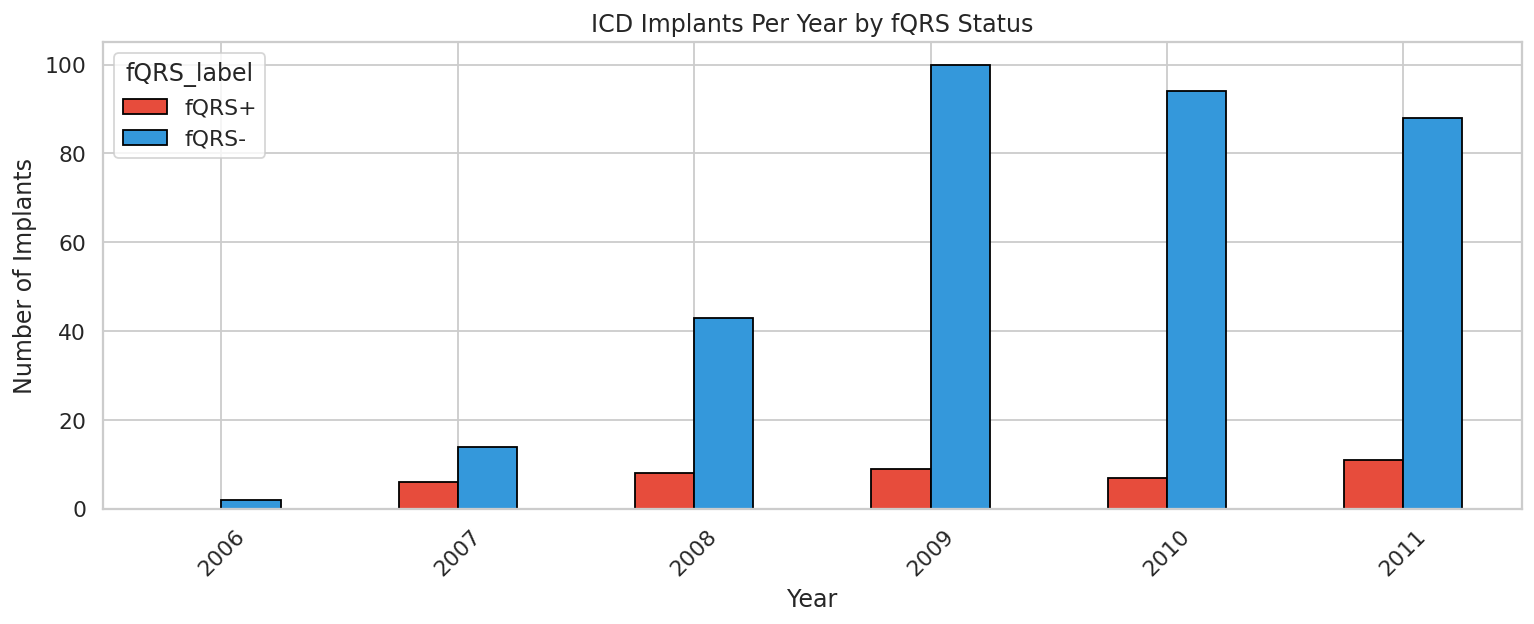

In [16]:
df_r['implant_date_parsed'] = pd.to_datetime(
    df['date of implant'], dayfirst=True, errors='coerce')
df_r['implant_year'] = df_r['implant_date_parsed'].dt.year

yearly = df_r.groupby(['implant_year', 'fQRS_label']).size().unstack(fill_value=0)

ax = yearly.plot(kind='bar', figsize=(12, 5), color=['#e74c3c','#3498db'],
                 edgecolor='black')
ax.set_title("ICD Implants Per Year by fQRS Status")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Implants")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()


        Variable  Z-score >3  IQR ×3 method   Min   Max
age (at implant)           4              0  17.0  89.0
             BMI           1              0  16.7  43.3
        LVEF (%)           8              0  10.0  60.0
      LVEDD (cm)           1              1   4.1  56.0
  QRS width (ms)           1              0  80.0 300.0
           HR /'           3              3  25.0 115.0
         QT (ms)           4              3 320.0 840.0
        QTc (ms)           4              1  80.0 739.0
             GFR           1              0  10.0 147.0


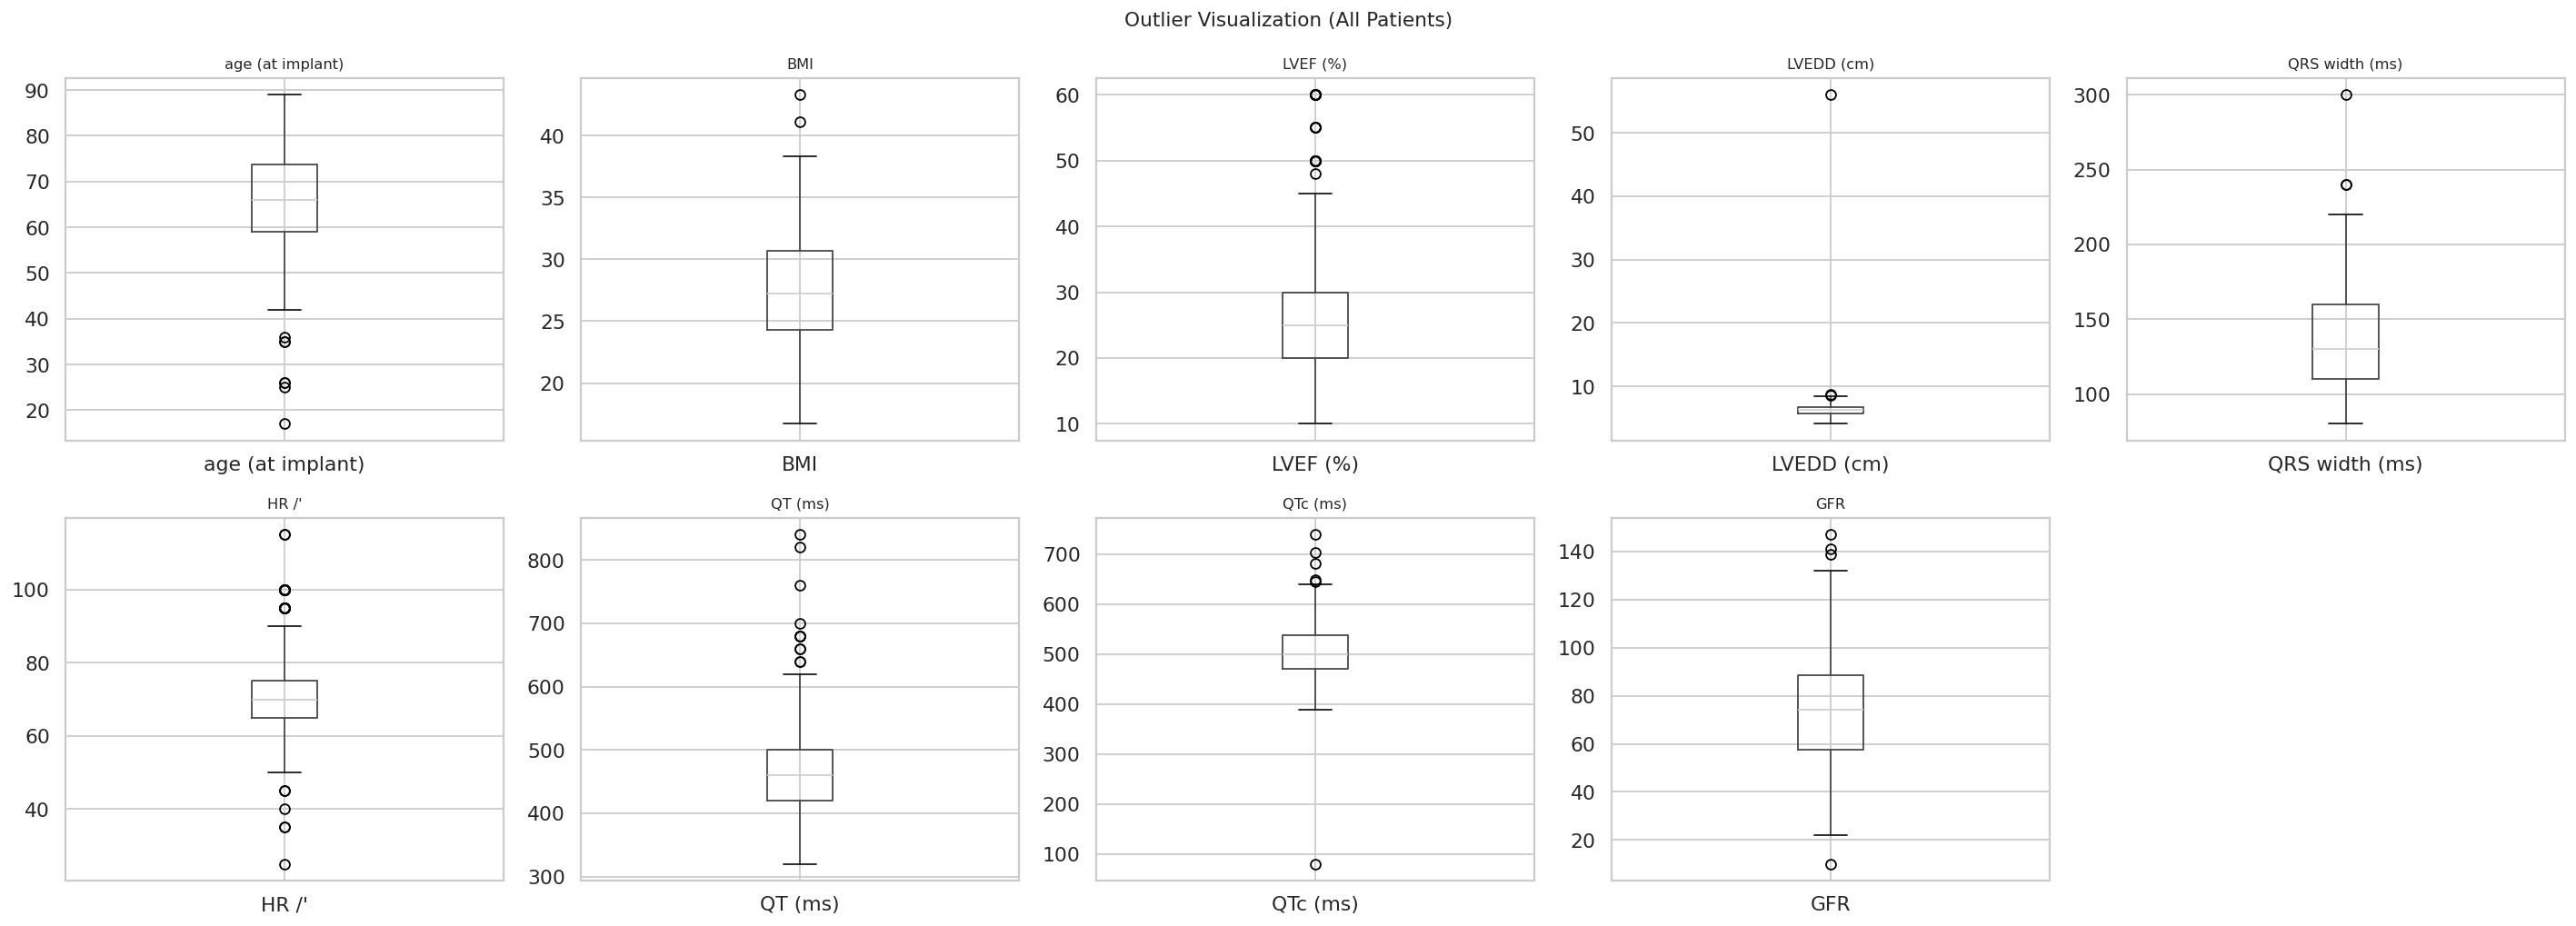

In [17]:
from scipy.stats import zscore

cont_vars_outlier = ['age (at implant)', 'BMI', 'LVEF (%)', 'LVEDD (cm)',
                     'QRS width (ms)', "HR /'", 'QT (ms)', 'QTc (ms)', 'GFR']

outlier_summary = []
for var in cont_vars_outlier:
    col_data = df_r[var].dropna()
    z = np.abs(zscore(col_data))
    iqr = col_data.quantile(0.75) - col_data.quantile(0.25)
    low, high = col_data.quantile(0.25) - 3*iqr, col_data.quantile(0.75) + 3*iqr
    outliers_z = (z > 3).sum()
    outliers_iqr = ((col_data < low) | (col_data > high)).sum()
    outlier_summary.append({'Variable': var, 'Z-score >3': outliers_z,
                             'IQR ×3 method': outliers_iqr,
                             'Min': col_data.min(), 'Max': col_data.max()})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# Box plots with all patients
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for i, var in enumerate(cont_vars_outlier):
    df_r.boxplot(column=var, ax=axes[i])
    axes[i].set_title(var, fontsize=9)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle("Outlier Visualization (All Patients)", fontsize=12)
plt.tight_layout()
plt.show()


In [18]:
print("=" * 65)
print("         RESEARCH EDA KEY FINDINGS SUMMARY")
print("=" * 65)

print(f"\n📌 COHORT: {len(df_r)} ICD patients")
print(f"   fQRS+: {df_r['fQRS'].sum()} ({df_r['fQRS'].mean()*100:.1f}%)")
print(f"   fQRS-: {(1-df_r['fQRS']).sum()} ({(1-df_r['fQRS'].mean())*100:.1f}%)")

print(f"\n📌 DEMOGRAPHICS")
print(f"   Median age: {df_r['age (at implant)'].median():.0f} yrs (IQR {df_r['age (at implant)'].quantile(0.25):.0f}–{df_r['age (at implant)'].quantile(0.75):.0f})")
print(f"   Male: {df_r['sex'].sum()} ({df_r['sex'].mean()*100:.1f}%)")

print(f"\n📌 CARDIAC FUNCTION")
print(f"   Median LVEF: {df_r['LVEF (%)'].median():.0f}% (IQR {df_r['LVEF (%)'].quantile(0.25):.0f}–{df_r['LVEF (%)'].quantile(0.75):.0f})")
print(f"   Median QRS width: {df_r['QRS width (ms)'].median():.0f} ms")

print(f"\n📌 CONDUCTION ABNORMALITIES")
for col, label in [('LBBB','LBBB'), ('RBBB','RBBB'), ('IVCD','IVCD')]:
    print(f"   {label}: {df_r[col].sum()} ({df_r[col].mean()*100:.1f}%)")

print(f"\n📌 MISSING DATA")
top_miss = (df_r.isnull().mean()*100).sort_values(ascending=False)
for col, pct in top_miss.head(5).items():
    print(f"   {col}: {pct:.1f}% missing")

print("\n✅ EDA Complete.")


         RESEARCH EDA KEY FINDINGS SUMMARY

📌 COHORT: 382 ICD patients
   fQRS+: 41 (10.7%)
   fQRS-: 341 (89.3%)

📌 DEMOGRAPHICS
   Median age: 66 yrs (IQR 59–74)
   Male: 319 (83.5%)

📌 CARDIAC FUNCTION
   Median LVEF: 25% (IQR 20–30)
   Median QRS width: 130 ms

📌 CONDUCTION ABNORMALITIES
   LBBB: 90.0 (23.6%)
   RBBB: 23.0 (6.0%)
   IVCD: 76.0 (19.9%)

📌 MISSING DATA
   intermittent BBB: 99.7% missing
   NSTEMI localization: 99.2% missing
   arrhythmia rate : 89.0% missing
   STEMI localization: 88.5% missing
   type of arrhythmia at implantation: 70.4% missing

✅ EDA Complete.
